In [ ]:
!pip install spatialdata squidpy
!pip install torch_geometric

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
from torch.utils.data import DataLoader

import scanpy as sc

import csv
import os
import sys
from filelock import FileLock
from tqdm import tqdm

os.chdir("/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis")
cwd = os.getcwd()
print(cwd)

sys.path.append("./")
import GNN as SA

if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"

/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis


## Breast Cancer

In [3]:
ad = sc.read_h5ad("../Breast_Cancer/all_embeddings_V1.h5ad")

In [4]:
HE_modal = 'UNI'
adata = sc.read_h5ad("../Breast_Cancer/all_embeddings_V1.h5ad")

adata.obsm['p_Morpho_Embedding'] = adata.obsm[HE_modal].copy()

adata = SA.prep_adata(adata, norm=True, log1p=True)
dataset = SA.build_graph(adata, k=8, morph_key='p_Morpho_Embedding')

/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis/GNN/dataset.py:13: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


In [5]:
for mn in tqdm(['UNI', 'NOMORPHO', 'NOISE']):
  save_dir = "/content/drive/MyDrive/Thesis/Projects/Data/Trained_Weights"
  SA.set_random_seed(20)
  model = SA.SpatialTransformerAE(
      in_dim=dataset.x.shape[1],
      gene_dim=dataset.gene_dim,
      hidden_dim=256,
      latent_dim=64,
      heads=4
  )
  model = model.to(device)
  model.load_state_dict(
          torch.load(
              os.path.join(save_dir,f'GNN_BC_MR_0.3_Seed_2_{mn}.pth'), map_location=torch.device(device),weights_only=True
              ), strict=False
              )
  with torch.no_grad():
    x_masked = SA.model.mask_features(dataset, 0.3)
    _, z = model(x_masked, dataset.edge_index, dataset.edge_attr, details=True)

  ad.obsm[f'GNN_{mn}'] = z.cpu().numpy()

100%|██████████| 3/3 [01:12<00:00, 24.23s/it]


... UMAP ...


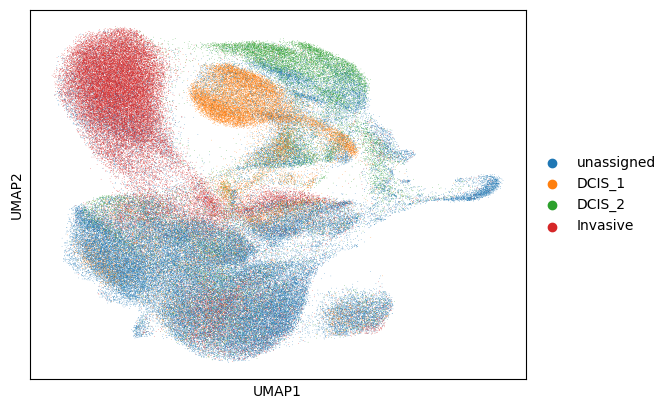

In [6]:
from sklearn.decomposition import PCA

ad_m = ad.copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'GNN_UNI'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

... UMAP ...


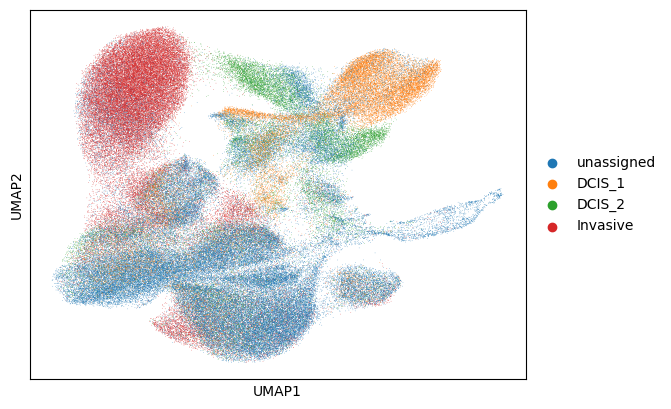

In [7]:
from sklearn.decomposition import PCA

ad_m = ad.copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'GNN_NOISE'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

... UMAP ...


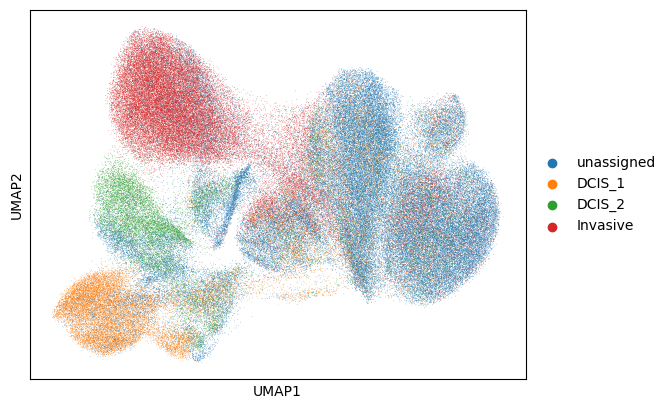

In [8]:
from sklearn.decomposition import PCA

ad_m = ad.copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'GNN_NOMORPHO'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

In [9]:
ad.write_h5ad("../Breast_Cancer/all_embeddings_V2.h5ad")

## Mouse Brain

In [10]:
ad = sc.read_h5ad("../Mouse_Brain/all_embeddings_V1.h5ad")

In [11]:
HE_modal = 'UNI'
adata = sc.read_h5ad("../Mouse_Brain/all_embeddings_3.h5ad")

adata.obsm['p_Morpho_Embedding'] = adata.obsm[HE_modal].copy()

adata = SA.prep_adata(adata, norm=True, log1p=True)
dataset = SA.build_graph(adata, k=8, morph_key='p_Morpho_Embedding')

/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis/GNN/dataset.py:13: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


In [12]:
for mn in tqdm(['UNI', 'NOMORPHO', 'NOISE']):
  save_dir = "/content/drive/MyDrive/Thesis/Projects/Data/Trained_Weights"
  SA.set_random_seed(20)
  model = SA.SpatialTransformerAE(
      in_dim=dataset.x.shape[1],
      gene_dim=dataset.gene_dim,
      hidden_dim=256,
      latent_dim=64,
      heads=4
  )
  model = model.to(device)
  model.load_state_dict(
          torch.load(
              os.path.join(save_dir,f'GNN_MB_MR_0.3_Seed_2_{mn}.pth'), map_location=torch.device(device),weights_only=True
              ), strict=False
              )
  with torch.no_grad():
    x_masked = SA.model.mask_features(dataset, 0.3)
    _, z = model(x_masked, dataset.edge_index, dataset.edge_attr, details=True)

  ad.obsm[f'GNN_{mn}'] = z.cpu().numpy()

100%|██████████| 3/3 [00:38<00:00, 12.98s/it]


... UMAP ...


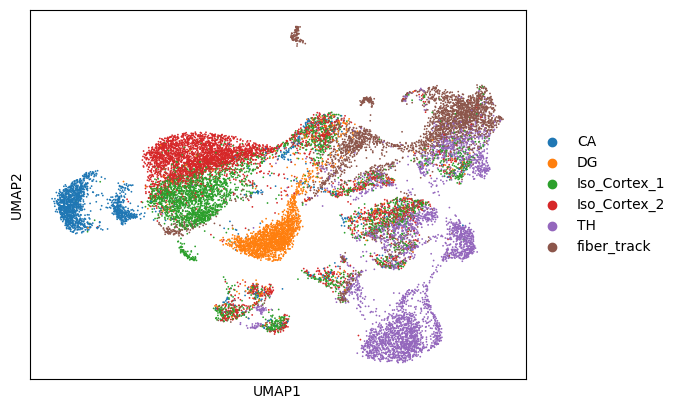

In [13]:
from sklearn.decomposition import PCA

mask = ad.obs['annotation'] == 'unassigned'
ad_m = ad[~mask].copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm['GNN_UNI'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

... UMAP ...


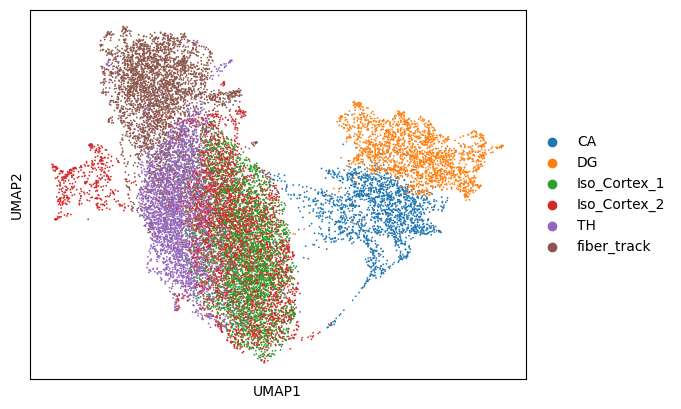

In [14]:
from sklearn.decomposition import PCA

mask = ad.obs['annotation'] == 'unassigned'
ad_m = ad[~mask].copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'GNN_NOISE'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

... UMAP ...


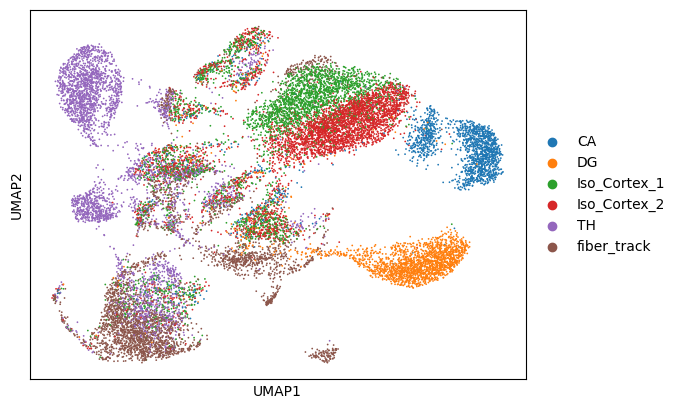

In [15]:
from sklearn.decomposition import PCA

mask = ad.obs['annotation'] == 'unassigned'
ad_m = ad[~mask].copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'GNN_NOMORPHO'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

In [16]:
ad.write_h5ad("../Mouse_Brain/all_embeddings_V2.h5ad")